In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('data/anemia.csv')
df.head()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [4]:
df.shape

(1421, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


In [6]:
df.isnull().sum()

Gender        0
Hemoglobin    0
MCH           0
MCHC          0
MCV           0
Result        0
dtype: int64

In [7]:
df['Gender'].value_counts()

Gender
1    740
0    681
Name: count, dtype: int64

In [8]:
df['Result'].value_counts()

Result
0    801
1    620
Name: count, dtype: int64

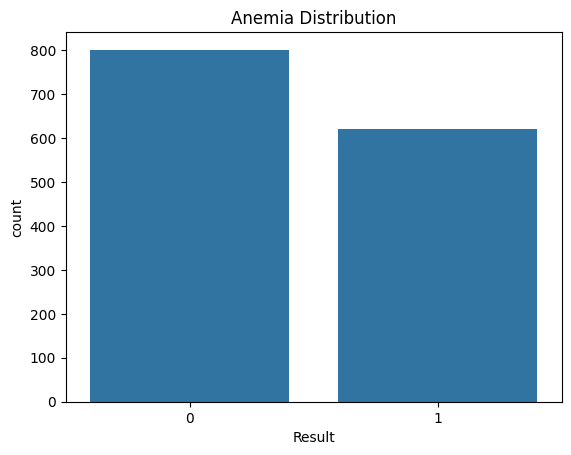

In [9]:
sns.countplot(x='Result',data=df)
plt.title('Anemia Distribution')
plt.show()

In [10]:
df.corr()['Result'].sort_values(ascending=False)

Result        1.000000
Gender        0.253169
MCHC          0.048067
MCV          -0.020571
MCH          -0.028678
Hemoglobin   -0.796261
Name: Result, dtype: float64

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X=df[['Gender','MCHC','MCV','MCH','Hemoglobin']]
y=df['Result']

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

models={
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM (linear)': SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred=model.predict(X_test_scaled)
    print(f"-----{name}-----")
    print(classification_report(y_test, y_pred))
    print(accuracy_score(y_test, y_pred))
    print()

-----Logistic Regression-----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       161
           1       1.00      1.00      1.00       124

    accuracy                           1.00       285
   macro avg       1.00      1.00      1.00       285
weighted avg       1.00      1.00      1.00       285

1.0

-----Random Forest-----
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       161
           1       1.00      0.91      0.95       124

    accuracy                           0.96       285
   macro avg       0.97      0.96      0.96       285
weighted avg       0.96      0.96      0.96       285

0.9614035087719298

-----SVM (linear)-----
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       161
           1       0.99      0.98      0.99       124

    accuracy                           0.99       285
   macro avg       0.99   

In [17]:
df.groupby('Result')[['Hemoglobin', 'MCH', 'MCHC', 'MCV']].describe()

Hemoglobin                             ...    MCV                    
            count       mean       std   min  ...    25%    50%   75%    max
Result                                        ...                           
0           801.0  14.795506  1.318837  12.0  ...  77.30  85.60  94.2  101.5
1           620.0  11.626290  1.012572   6.6  ...  77.25  84.55  94.2  101.6

[2 rows x 32 columns]

In [25]:
import joblib
svm_final=models['SVM (linear)']
joblib.dump(svm_final,'anemia_svm_model.pkl')
joblib.dump(scaler,'anemia_scaler.pkl')
joblib.dump(['Gender','MCHC','MCV','MCH','Hemoglobin'],'anemia_columns.pkl')
print("Anemia SVM model saved!")

Anemia SVM model saved!


In [24]:
test_healthy = pd.DataFrame([{
    'Gender': 0, 'MCHC': 33, 'MCV': 90, 'MCH': 29, 'Hemoglobin': 13.5
}])
test_healthy = test_healthy[['Gender', 'MCHC', 'MCV', 'MCH', 'Hemoglobin']]
test_scaled = scaler.transform(test_healthy)
print("Healthy - Prediction:", svm_final.predict(test_scaled), "Score:", svm_final.decision_function(test_scaled))

test_anemic = pd.DataFrame([{
    'Gender': 0, 'MCHC': 28, 'MCV': 75, 'MCH': 22, 'Hemoglobin': 8.0
}])
test_anemic = test_anemic[['Gender', 'MCHC', 'MCV', 'MCH', 'Hemoglobin']]
test_scaled2 = scaler.transform(test_anemic)
print("Anemic - Prediction:", svm_final.predict(test_scaled2), "Score:", svm_final.decision_function(test_scaled2))

Healthy - Prediction: [0] Score: [-4.67852886]
Anemic - Prediction: [1] Score: [11.03089832]
